# Electricity Malpractice Detection Using Smart Meter Data

## Objective
Identify abnormal electricity consumption patterns that may indicate:

- Faulty meters
- Electricity theft
- Grid instability
- Abnormal voltage or current behaviour

Dataset: India Smart Meter Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/raw/smart_meter_india.csv")

df.head()

,timestamp,consumption_kWh,Avg Voltage (Volt),Avg Current (Amp),Freq (Hz),meter
0,1/1/2020 0:00,0.002,251.26,0.15,49.97,BR02
1,1/1/2020 0:03,0.001,251.23,0.15,49.94,BR02
2,1/1/2020 0:06,0.001,251.55,0.14,49.94,BR02
3,1/1/2020 0:09,0.001,251.97,0.14,50.09,BR02
4,1/1/2020 0:12,0.002,252.03,0.14,50.08,BR02


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   timestamp           1048575 non-null  str    
 1   consumption_kWh     1048575 non-null  float64
 2   Avg Voltage (Volt)  1048575 non-null  float64
 3   Avg Current (Amp)   1048575 non-null  float64
 4   Freq (Hz)           1048575 non-null  float64
 5   meter               1048575 non-null  str    
dtypes: float64(4), str(2)
memory usage: 66.5 MB


In [4]:
df = df.rename(columns={
    "Avg Voltage (Volt)": "voltage",
    "Avg Current (Amp)": "current",
    "Freq (Hz)": "frequency"
})

df.head()

,timestamp,consumption_kWh,voltage,current,frequency,meter
0,1/1/2020 0:00,0.002,251.26,0.15,49.97,BR02
1,1/1/2020 0:03,0.001,251.23,0.15,49.94,BR02
2,1/1/2020 0:06,0.001,251.55,0.14,49.94,BR02
3,1/1/2020 0:09,0.001,251.97,0.14,50.09,BR02
4,1/1/2020 0:12,0.002,252.03,0.14,50.08,BR02


In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [9]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

In [10]:
df.describe()

,timestamp,consumption_kWh,voltage,current,frequency,hour,day,month
count,429600,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,429600.000000,429600.000000,429600.000000
mean,2020-06-22 00:07:20.949721,1.663508e-02,2.347987e+02,1.597843e+00,4.800800e+01,11.500000,6.290503,6.496089
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000,1.000000
25%,2020-03-12 08:23:15,3.000000e-03,2.375100e+02,3.500000e-01,4.996000e+01,5.750000,3.000000,3.000000
50%,2020-06-12 16:46:30,9.000000e-03,2.455900e+02,9.300000e-01,5.000000e+01,11.500000,6.000000,6.000000
75%,2020-10-01 16:57:45,1.800000e-02,2.516200e+02,1.900000e+00,5.004000e+01,17.250000,9.000000,10.000000
max,2020-12-12 23:57:00,3.000000e-01,2.992600e+02,2.436000e+01,2.083300e+02,23.000000,12.000000,12.000000
std,NaN,2.343552e-02,4.878975e+01,2.005914e+00,9.786691e+00,6.922195,3.406286,3.474691


In [11]:
df.isnull().sum()

timestamp          618975
consumption_kWh         0
voltage                 0
current                 0
frequency               0
meter                   0
hour               618975
day                618975
month              618975
dtype: int64

In [13]:
meter_consumption = df.groupby("meter")["consumption_kWh"].sum().reset_index()

meter_consumption.sort_values(by="consumption_kWh", ascending=False).head()

,meter,consumption_kWh
4,BR06,5142.810
2,BR04,3800.528
5,BR07,2517.371
6,BR08,2483.802
0,BR02,1222.404


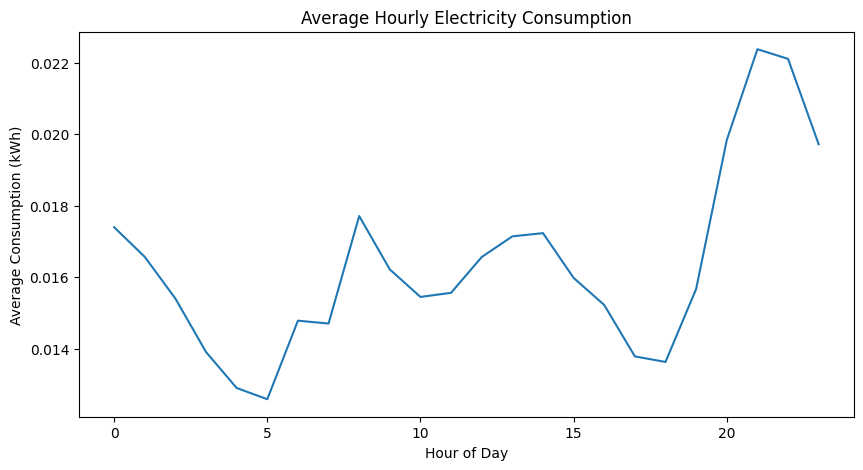

In [14]:
hourly_usage = df.groupby("hour")["consumption_kWh"].mean()

hourly_usage.plot(figsize=(10,5))

plt.title("Average Hourly Electricity Consumption")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (kWh)")
plt.show()

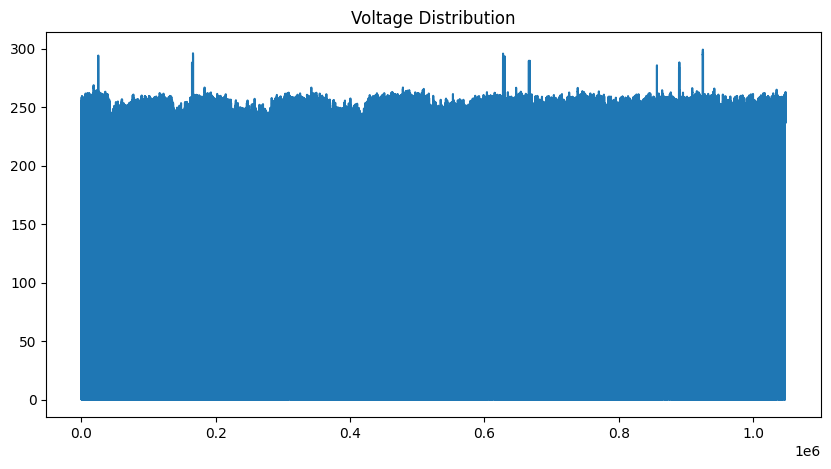

In [15]:
df['voltage'].plot(figsize=(10,5))
plt.title("Voltage Distribution")
plt.show()

Text(0.5, 1.0, 'Voltage Distribution')

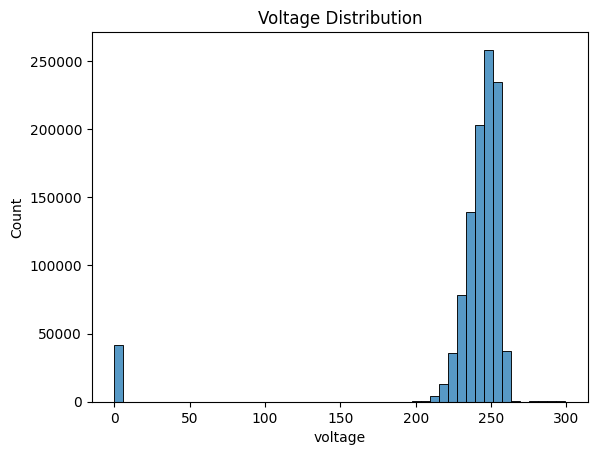

In [16]:
sns.histplot(df['voltage'], bins=50)
plt.title("Voltage Distribution")

In [17]:
threshold = df['consumption_kWh'].mean() + 3 * df['consumption_kWh'].std()

df['anomaly'] = df['consumption_kWh'] > threshold

In [18]:
df[df['anomaly']==True].head()

,timestamp,consumption_kWh,voltage,current,frequency,meter,hour,day,month,anomaly
25200,2020-07-03 12:00:00,0.088,290.07,7.51,50.00,BR02,12.0,3.0,7.0,True
25201,2020-07-03 12:03:00,0.091,288.99,7.42,50.00,BR02,12.0,3.0,7.0,True
25204,2020-07-03 12:12:00,0.092,289.47,7.16,50.00,BR02,12.0,3.0,7.0,True
70335,NaT,0.092,228.94,8.73,49.98,BR02,NaN,NaN,NaN,True
100449,2020-10-12 06:27:00,0.098,250.86,8.82,50.00,BR02,6.0,12.0,10.0,True


In [19]:
suspicious_meters = df[df['anomaly']==True].groupby("meter").size()

suspicious_meters.sort_values(ascending=False).head(10)

meter
BR06    17275
BR07     5209
BR04     2529
BR08      350
BR05       88
BR02        7
dtype: int64

Text(0.5, 1.0, 'Consumption Distribution')

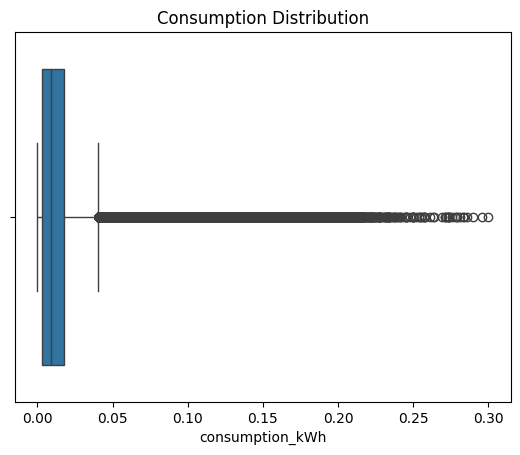

In [21]:
sns.boxplot(x=df['consumption_kWh'])
plt.title("Consumption Distribution")

Text(0.5, 1.0, 'Current vs Consumption')

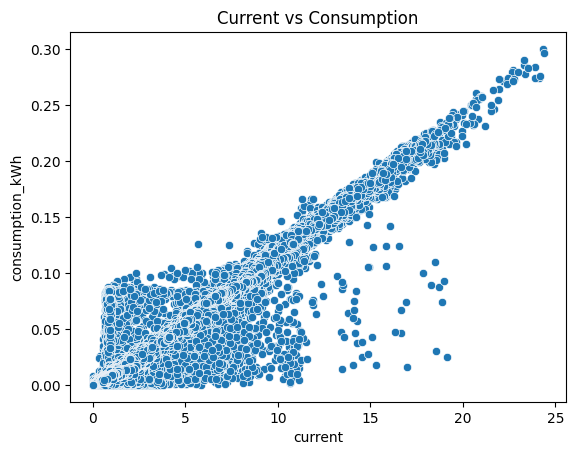

In [22]:
sns.scatterplot(x="current", y="consumption_kWh", data=df)
plt.title("Current vs Consumption")

Text(0.5, 1.0, 'Grid Frequency Distribution')

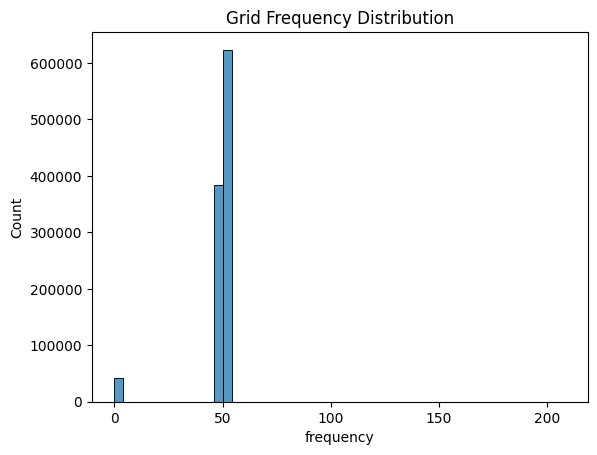

In [23]:
sns.histplot(df['frequency'], bins=50)
plt.title("Grid Frequency Distribution")

In [25]:
df.to_csv("data/cleaned/smart_meter_processed.csv", index=False)